# Analysis of Global Scientific Production (2000–2025)

In this notebook, we examine the scientific output of the 15 most productive countries according to Scimago Journal & Country Rank (https://www.scimagojr.com/countryrank.php). Using data obtained through the OpenAlex API (https://openalex.org), we collect the number of published scientific articles per year from 2000 to 2025 for each country.

The analysis is performed in two complementary ways:
* Absolute production — the total number of articles published each year, showing the evolution of global research output and revealing how different countries have contributed to its growth.

* Normalized production — each country’s publication counts are divided by their respective 2025 value, allowing comparison of relative growth trends independently of total size.

Finally, we compute the median normalized profile across all countries to obtain a representative global trend of scientific production over the past 25 years.

## Results

The median curve shows a distinct **rise-and-fall** pattern in global scientific production between 2000 and 2024.

From 2000 to around 2020, the normalized median number of articles increases steadily, with an average annual growth rate of about 5.3 % (slope = 0.053). This long ascent reflects a broad expansion of worldwide research capacity, increased international collaboration, and the continuous growth of indexed journals and research funding.

After peaking near 2020, the trend reverses: the normalized median declines at an average annual rate of roughly 13.8% (slope = –0.138). This downturn points to a contraction following two decades of rapid growth. Possible causes include the COVID-19 pandemic’s disruption of research activity, changes in publication incentives, and a slowdown in funding growth in some major economies.

Overall, the curve captures a 20-year phase of expansion followed by a recent and sharper decline, indicating that the remarkable rise in global scientific production that characterized the early 21st century has begun to recede in the most recent years.

In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

In [14]:
def getWorksFromCountryAll(country):
  base = "https://api.openalex.org/works"
  params = {
      # institution lineage, type=article, and year range
      "filter": f"authorships.institutions.country_code:{country},type:article,publication_year:2000-2025",
      # be nice to their API
      "mailto": "coss@cnb.csic.es",
      # group counts by year
      "group_by": "publication_year",
      # large page size to return all groups in one shot
      "per_page": 200,
  }

  r = requests.get(base, params=params, timeout=60)
  r.raise_for_status()
  data = r.json()

  # The response has groups with {"key": "YYYY", "count": N}
  groups = data.get("group_by") or data  # some clients show a bare list; handle both
  df = pd.DataFrame(groups)
  df["year"] = df["key"].astype(int)
  df["count"] = df["count"].astype(float)
  df = df.sort_values("year", ascending=True)[["year", "count"]].reset_index(drop=True)
  df.loc[df["year"] == 2025, "count"] *= 1.2

  return df

In [15]:
works={}
works["US"]=getWorksFromCountryAll("US")
works["CN"]=getWorksFromCountryAll("CN")
works["GB"]=getWorksFromCountryAll("GB")
works["DE"]=getWorksFromCountryAll("DE")
works["JP"]=getWorksFromCountryAll("JP")
works["IN"]=getWorksFromCountryAll("IN")
works["FR"]=getWorksFromCountryAll("FR")
works["IT"]=getWorksFromCountryAll("IT")
works["CA"]=getWorksFromCountryAll("CA")
works["AU"]=getWorksFromCountryAll("AU")
works["ES"]=getWorksFromCountryAll("ES")
works["RU"]=getWorksFromCountryAll("RU")
works["KR"]=getWorksFromCountryAll("KR")
works["BR"]=getWorksFromCountryAll("BR")
works["NL"]=getWorksFromCountryAll("NL")

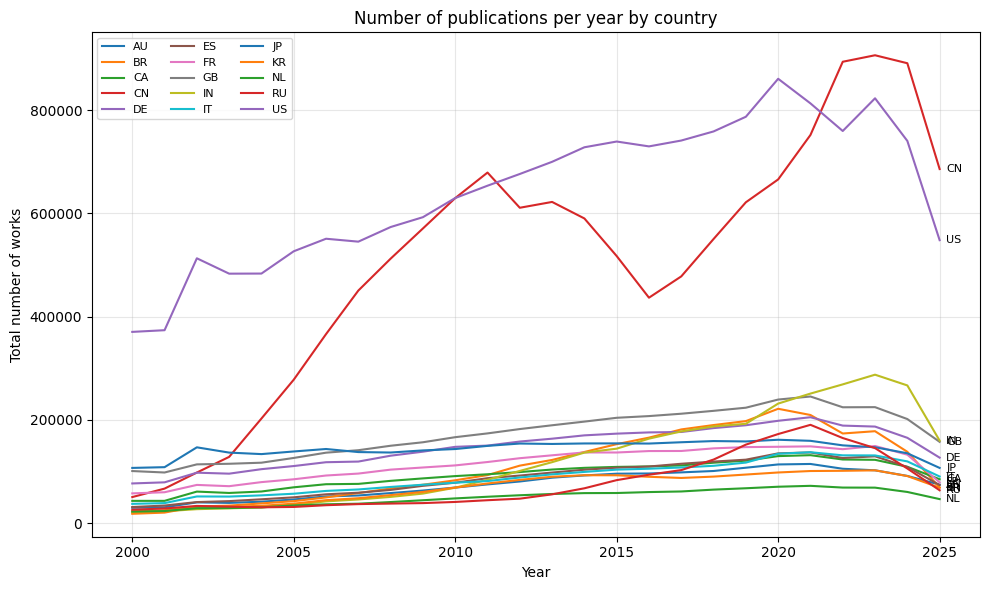

In [16]:
def plot_country_publications(country_dfs, title, ylabel, labelPosition):
    """
    country_dfs: dict like {'US': dfUS, 'CN': dfCN, ...}
                 each df has columns ['year', 'count']
    """
    plt.figure(figsize=(10,6))

    for country, df in sorted(country_dfs.items()):
        df_sorted = df.sort_values("year")
        plt.plot(df_sorted["year"], df_sorted["count"], label=country, linewidth=1.5)

        if labelPosition==1:
          # Add label at the end of the line (rightmost point)
          x = df_sorted["year"].iloc[-1]
          y = df_sorted["count"].iloc[-1]
          plt.text(x + 0.2, y, country, fontsize=8, va='center')
        elif labelPosition==-1:
          # Add label at the end of the line (leftmost point)
          x = df_sorted["year"].iloc[0]
          y = df_sorted["count"].iloc[0]
          plt.text(x - 0.8, y, country, fontsize=8, va='center')

    plt.title(title)
    plt.xlabel("Year")
    plt.ylabel(ylabel)
    plt.legend(ncol=3, fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
plot_country_publications(works, "Number of publications per year by country",
                          "Total number of works", 1)

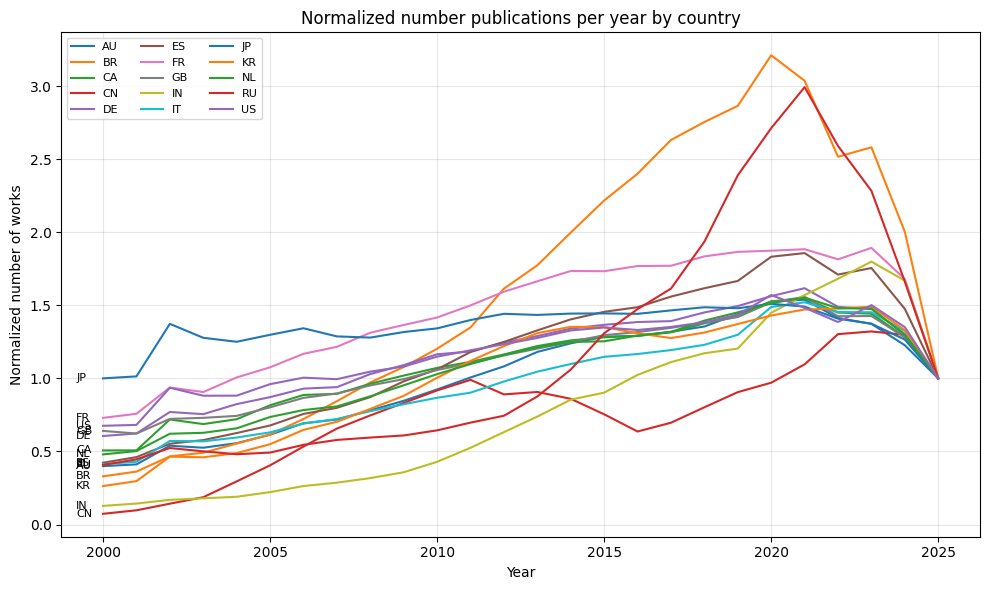

In [17]:
worksNormalized = {
        country: df.assign(count=df["count"] / df["count"].iloc[-1])
        for country, df in works.items()
    }
plot_country_publications(worksNormalized, "Normalized number publications per year by country",
                          "Normalized number of works", -1)

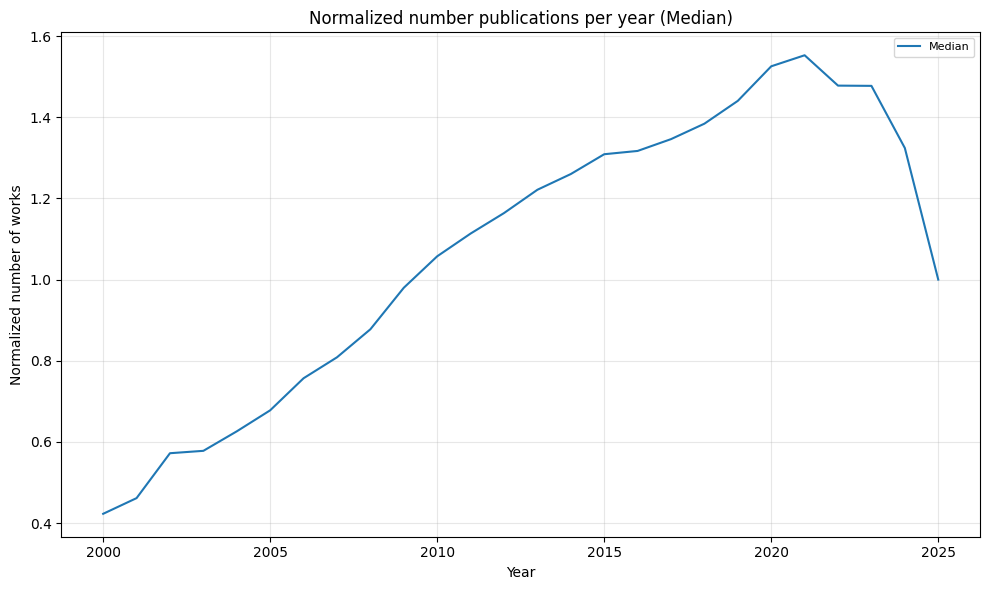

In [18]:
df_all = pd.concat(
    {country: df.set_index("year")["count"] for country, df in worksNormalized.items()},
    axis=1
)

# Compute the median across countries for each year
median_per_year = df_all.median(axis=1, skipna=True)

# Optionally convert to a DataFrame for plotting or export
median_df = median_per_year.reset_index()
median_df.columns = ["year", "count"]

worksMedian = {"Median": median_df}
plot_country_publications(worksMedian, "Normalized number publications per year (Median)",
                          "Normalized number of works", 0)

In [19]:
median_df

,year,count
0,2000,0.422885
1,2001,0.461513
2,2002,0.572157
3,2003,0.578034
4,2004,0.626075
5,2005,0.677886
6,2006,0.756905
7,2007,0.808506
8,2008,0.877593
9,2009,0.979870


In [21]:
slopeUp=(median_df['count'][21]-median_df['count'][0])/21
slopeDown=(median_df['count'][25]-median_df['count'][21])/4
print(f"Slope up={slopeUp}; Slope down={slopeDown}")

Slope up=0.053805584367502796; Slope down=-0.13820066035545697


In [24]:
ratios = (pd.Series({c: (df.set_index("year").loc[2025, "count"] / df.set_index("year").loc[2021, "count"]-1)*100
                     for c, df in works.items()})
          .sort_values(ascending=False))

print("Change from 2021 to 2025 (in %):")
print(ratios.round(1))

Change from 2021 to 2025 (in %):
CN    -8.8
KR   -32.1
US   -32.6
JP   -32.9
IT   -34.3
AU   -35.0
CA   -35.4
NL   -35.6
GB   -35.8
IN   -36.3
DE   -38.2
ES   -46.2
FR   -46.9
RU   -66.6
BR   -67.1
dtype: float64


In [27]:
def years_lost_to_2025(df):
    s = df.set_index("year")["count"].dropna()
    if 2024 not in s.index:
        return np.nan, np.nan  # no 2025 data
    c2025 = s.loc[2025]
    # prior years only
    prior = s.loc[s.index <= 2024]
    if prior.empty:
        return np.nan, np.nan
    y_closest = (prior - c2025).abs().idxmin()
    lost = 2025 - y_closest
    return int(lost), int(y_closest)

decliners = ratios[ratios < 0].index
lost_info = {
    c: years_lost_to_2025(works[c]) for c in decliners
}

lost_df = (pd.DataFrame(lost_info, index=["years_lost","closest_year"])
             .T.sort_values("years_lost", ascending=False))

print(lost_df)
print(f"Mean = {lost_df['years_lost'].mean():.1f}")

    years_lost  closest_year
JP          25          2000
FR          21          2004
US          19          2006
DE          17          2008
BR          17          2008
GB          16          2009
CA          16          2009
ES          16          2009
NL          15          2010
KR          15          2010
CN          14          2011
AU          14          2011
IT          13          2012
RU          11          2014
IN           9          2016
Mean = 15.9
